## MODEL TRAINING 


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier


In [2]:
file_path = "../dataset/processed/paysim_processed.csv"

df = pd.read_csv(
    file_path,
    nrows=500000
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (500000, 18)


In [3]:
df.head()

,event_id,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,balance_change_orig,balance_change_dest,amount_to_orig_balance,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.0,0,9839.64,0.0,0.057834,0,0,0,1,0
1,1,1,5157.05,C1562950869,1667.92,0.00,M2021835850,0.0,0.0,0,1667.92,0.0,3.090052,0,0,0,1,0
2,2,1,5746.44,C845388562,0.00,0.00,M550572371,0.0,0.0,0,0.00,0.0,5746.440000,0,0,0,1,0
3,3,1,5607.36,C948424584,5202.00,0.00,M1447685190,0.0,0.0,0,5202.00,0.0,1.077717,0,0,0,1,0
4,4,1,6360.79,C2027701910,3731.00,0.00,M1345293143,0.0,0.0,0,3731.00,0.0,1.704392,0,0,0,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   event_id                500000 non-null  int64  
 1   step                    500000 non-null  int64  
 2   amount                  500000 non-null  float64
 3   nameOrig                500000 non-null  str    
 4   oldbalanceOrg           500000 non-null  float64
 5   newbalanceOrig          500000 non-null  float64
 6   nameDest                500000 non-null  str    
 7   oldbalanceDest          500000 non-null  float64
 8   newbalanceDest          500000 non-null  float64
 9   isFraud                 500000 non-null  int64  
 10  balance_change_orig     500000 non-null  float64
 11  balance_change_dest     500000 non-null  float64
 12  amount_to_orig_balance  500000 non-null  float64
 13  type_CASH_IN            500000 non-null  int64  
 14  type_CASH_OUT           500000 

In [5]:
print(df["isFraud"].value_counts())

isFraud
0    499767
1       233
Name: count, dtype: int64


In [6]:
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    99.9534
1     0.0466
Name: proportion, dtype: float64


In [7]:
feature_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_change_orig",
    "balance_change_dest",
    "amount_to_orig_balance",
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

In [8]:
X = df[feature_columns]

y = df["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500000, 14)
y shape: (500000,)


In [9]:
X.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: isFraud, dtype: int64

## cronological train test

In [10]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400000, 14)
Testing data: (100000, 14)


In [11]:
print("Training fraud:")
print(y_train.value_counts())
print("Testing fraud:")
print(y_test.value_counts())

Training fraud:
isFraud
0    399795
1       205
Name: count, dtype: int64
Testing fraud:
isFraud
0    99972
1       28
Name: count, dtype: int64


In [12]:
"""scaling data for logistic regression"""

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## logistic regression


In [13]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=200,
    solver="lbfgs"
)

lr_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [14]:
""" prediction """
lr_probability = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_prediction = (lr_probability >= 0.5).astype(int)


"""evaluation """

lr_precision = precision_score(
    y_test,
    lr_prediction,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_prediction,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_prediction,
    zero_division=0
)

lr_pr_auc = average_precision_score(
    y_test,
    lr_probability
)

lr_roc_auc = roc_auc_score(
    y_test,
    lr_probability
)

In [15]:
print("Logistic Regression Results")
print("---------------------------")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("PR-AUC:", lr_pr_auc)
print("ROC-AUC:", lr_roc_auc)

Logistic Regression Results
---------------------------
Precision: 0.027450980392156862
Recall: 0.75
F1 Score: 0.05296343001261034
PR-AUC: 0.5008640398897997
ROC-AUC: 0.9729574280798623


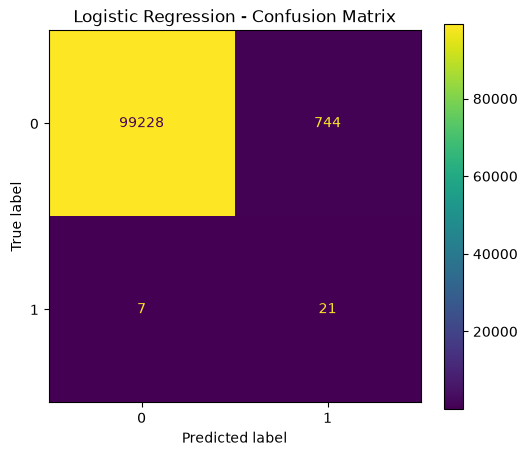

Logistic Regression confusion matrix saved successfully.


In [16]:


fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_prediction,
    ax=ax
)

ax.set_title("Logistic Regression - Confusion Matrix")

# Save image
plt.savefig(
    "../result/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Logistic Regression confusion matrix saved successfully.")

## random forest

In [17]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=2
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
""" prediction """
rf_probability = rf_model.predict_proba(X_test)[:, 1]

rf_prediction = (rf_probability >= 0.5).astype(int)


"""evaluation """

rf_precision = precision_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_probability
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

In [19]:
print("Random Forest Results")
print("---------------------------")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("PR-AUC:", rf_pr_auc)
print("ROC-AUC:", rf_roc_auc)

Random Forest Results
---------------------------
Precision: 1.0
Recall: 0.8928571428571429
F1 Score: 0.9433962264150944
PR-AUC: 0.9302130456852791
ROC-AUC: 0.9795376634028957


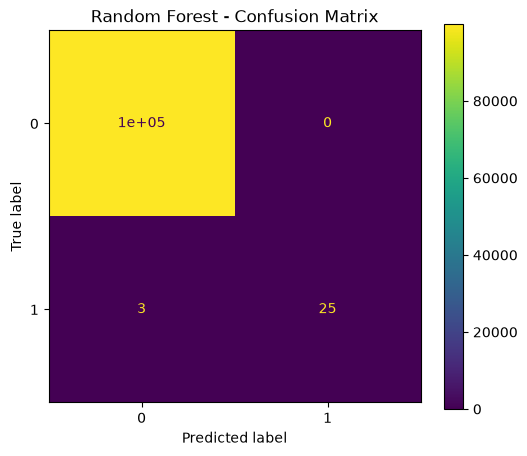

Random Forest confusion matrix saved successfully.


In [20]:


fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_prediction,
    ax=ax
)

ax.set_title("Random Forest - Confusion Matrix")

plt.savefig(
    "../result/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Random Forest confusion matrix saved successfully.")

## xgboost

In [21]:
"""handling class imbalance for xgboost"""

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1950.219512195122


In [22]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=2
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [23]:
""" prediction """
xgb_probability = xgb_model.predict_proba(X_test)[:, 1]

xgb_prediction = (xgb_probability >= 0.5).astype(int)


"""evaluation """

xgb_precision = precision_score(
    y_test,
    xgb_prediction,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_prediction,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_prediction,
    zero_division=0
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_probability
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

In [24]:
print("XGBoost Results")
print("---------------------------")
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)
print("PR-AUC:", xgb_pr_auc)
print("ROC-AUC:", xgb_roc_auc)

XGBoost Results
---------------------------
Precision: 0.5111111111111111
Recall: 0.8214285714285714
F1 Score: 0.6301369863013698
PR-AUC: 0.8307695350312932
ROC-AUC: 0.9728366799846814


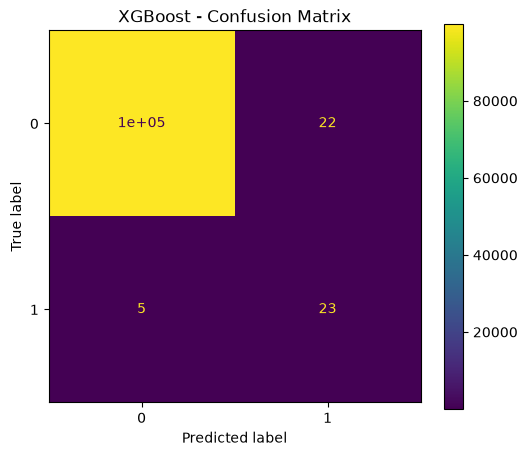

XGBoost confusion matrix saved successfully.


In [25]:


fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_prediction,
    ax=ax
)

ax.set_title("XGBoost - Confusion Matrix")

# Save image
plt.savefig(
    "../result/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("XGBoost confusion matrix saved successfully.")

## model comparison

In [26]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Precision": [lr_precision, rf_precision, xgb_precision],
    "Recall": [lr_recall, rf_recall, xgb_recall],
    "F1 Score": [lr_f1, rf_f1, xgb_f1],
    "PR-AUC": [lr_pr_auc, rf_pr_auc, xgb_pr_auc],
    "ROC-AUC": [lr_roc_auc, rf_roc_auc, xgb_roc_auc]
})

comparison_df

,Model,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
0,Logistic Regression,0.027451,0.750000,0.052963,0.500864,0.972957
1,Random Forest,1.000000,0.892857,0.943396,0.930213,0.979538
2,XGBoost,0.511111,0.821429,0.630137,0.830770,0.972837


## saving models

In [27]:
models_folder = "../models"

os.makedirs(models_folder, exist_ok=True)

joblib.dump(lr_model, f"{models_folder}/logistic_regression.pkl")
joblib.dump(scaler, f"{models_folder}/scaler.pkl")
joblib.dump(rf_model, f"{models_folder}/random_forest.pkl")
joblib.dump(xgb_model, f"{models_folder}/xgboost.pkl")

print("All models saved successfully.")

All models saved successfully.
